In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

first, we simulate user level ad data

each user:
- may or may not be in treatment group
- gets some impressions
- clicks based on probability
- converts based on probability

treatment group has slightly higher ctr and conversion rate

so we create a dataset that behaves like real ad system

In [2]:
def simulate_data(n=100000, seed=42):
    np.random.seed(seed)

    user_id = np.arange(n)

    treatment = np.random.binomial(1, 0.5, n)

    impressions = np.random.randint(5, 50, n)

    base_ctr = 0.05
    uplift_ctr = 0.02

    ctr = base_ctr + treatment * uplift_ctr
    clicks = np.random.binomial(impressions, ctr)

    base_cvr = 0.1
    uplift_cvr = 0.03

    cvr = base_cvr + treatment * uplift_cvr
    conversions = np.random.binomial(clicks, cvr)

    df = pd.DataFrame({
        "user_id": user_id,
        "treatment": treatment,
        "impressions": impressions,
        "clicks": clicks,
        "conversions": conversions
    })

    return df

df = simulate_data()
df.head()

,user_id,treatment,impressions,clicks,conversions
0,0,0,38,3,1
1,1,1,12,0,0
2,2,1,19,1,0
3,3,1,21,2,0
4,4,0,10,1,0


now we compute basic metrics

we split data into:
- control group
- treatment group

then compute:
- ctr = clicks / impressions
- conversion rate = conversions / clicks

then we compute lift:
difference between treatment and control

this tells us if new ad is better or not

In [3]:
def compute_metrics(df):
    control = df[df["treatment"] == 0]
    treatment = df[df["treatment"] == 1]

    ctr_control = control["clicks"].sum() / control["impressions"].sum()
    ctr_treat = treatment["clicks"].sum() / treatment["impressions"].sum()

    cvr_control = control["conversions"].sum() / max(control["clicks"].sum(), 1)
    cvr_treat = treatment["conversions"].sum() / max(treatment["clicks"].sum(), 1)

    return {
        "ctr_control": ctr_control,
        "ctr_treatment": ctr_treat,
        "ctr_lift": ctr_treat - ctr_control,
        "cvr_control": cvr_control,
        "cvr_treatment": cvr_treat,
        "cvr_lift": cvr_treat - cvr_control
    }

metrics = compute_metrics(df)
metrics

{'ctr_control': 0.049985221773402005,
 'ctr_treatment': 0.0699473691227249,
 'ctr_lift': 0.01996214734932289,
 'cvr_control': 0.09898040842941404,
 'cvr_treatment': 0.13035789919525625,
 'cvr_lift': 0.03137749076584222}

now we check if difference is actually meaningful

maybe treatment looks better just due to randomness

so we use t-test

idea:
- null hypothesis: no difference
- alternative: treatment is better

p-value tells us how likely this difference is due to chance

In [4]:
control_clicks = df[df["treatment"] == 0]["clicks"]
treatment_clicks = df[df["treatment"] == 1]["clicks"]

t_stat, p_value = stats.ttest_ind(treatment_clicks, control_clicks, equal_var=False)

t_stat, p_value

(57.68100422886767, 0.0)

instead of relying only on t-test, we estimate uncertainty

we repeatedly resample data with replacement

each time we compute lift

this gives a distribution of possible lifts

then we take:
- lower bound
- upper bound

this gives confidence interval for uplift

In [6]:
def bootstrap_lift(df, n_bootstrap=1000):
    lifts = []

    for _ in range(n_bootstrap):
        sample = df.sample(frac=1, replace=True)

        control = sample[sample["treatment"] == 0]
        treatment = sample[sample["treatment"] == 1]

        ctr_control = control["clicks"].sum() / control["impressions"].sum()
        ctr_treat = treatment["clicks"].sum() / treatment["impressions"].sum()

        lifts.append(ctr_treat - ctr_control)

    return lifts

lifts = bootstrap_lift(df)

np.percentile(lifts, [2.5, 97.5])

array([0.01939601, 0.0205344 ])

now we visualize results

first plot:
- compare ctr of control vs treatment

second plot:
- distribution of uplift values from bootstrap

this helps us see:
- how strong the effect is
- how uncertain it is

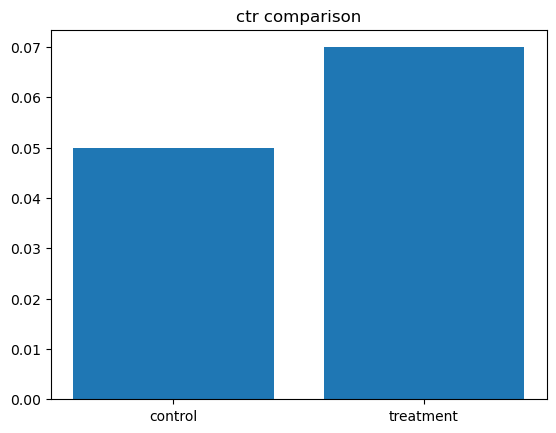

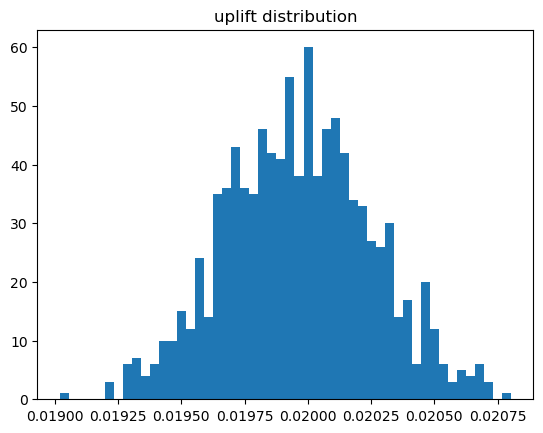

In [7]:
plt.figure()
plt.bar(["control", "treatment"], [metrics["ctr_control"], metrics["ctr_treatment"]])
plt.title("ctr comparison")
plt.show()

plt.figure()
plt.hist(lifts, bins=50)
plt.title("uplift distribution")
plt.show()

now we try to estimate effect using regression

idea:
control for other variables like impressions

we fit a model:
click ~ treatment + impressions

coefficient of treatment gives adjusted effect

this helps reduce bias

In [8]:
X = df[["treatment", "impressions"]]
y = (df["clicks"] > 0).astype(int)

model = LogisticRegression(max_iter=1000)
model.fit(X, y)

model.coef_

array([[0.65611724, 0.08541779]])

now we go one step deeper into causal learning

instead of one model, we train two models:
- one on treatment group
- one on control group

then for each user:
- predict outcome if treated
- predict outcome if not treated

difference gives uplift

average uplift gives causal effect

In [9]:
treated = df[df["treatment"] == 1]
control = df[df["treatment"] == 0]

model_t = LogisticRegression(max_iter=1000)
model_c = LogisticRegression(max_iter=1000)

model_t.fit(treated[["impressions"]], (treated["clicks"] > 0).astype(int))
model_c.fit(control[["impressions"]], (control["clicks"] > 0).astype(int))

X_all = df[["impressions"]]

pred_t = model_t.predict_proba(X_all)[:, 1]
pred_c = model_c.predict_proba(X_all)[:, 1]

uplift = np.mean(pred_t - pred_c)

uplift

0.10335714616091765

now we check if effect is same for all users

maybe some users respond more than others

so we:
- group users based on impressions
- compute effect in each group

this shows how treatment effect varies across segments

In [10]:
df["bucket"] = pd.qcut(df["impressions"], 5)

group_effect = df.groupby(["bucket", "treatment"])["clicks"].mean().unstack()

group_effect["uplift"] = group_effect[1] - group_effect[0]

group_effect

C:\Users\91829\AppData\Local\Temp\ipykernel_26140\322811184.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_effect = df.groupby(["bucket", "treatment"])["clicks"].mean().unstack()


treatment,0,1,uplift
bucket,,,
"(4.999, 14.0]",0.472455,0.678911,0.206457
"(14.0, 22.0]",0.917393,1.281607,0.364214
"(22.0, 32.0]",1.370454,1.920731,0.550278
"(32.0, 41.0]",1.868076,2.589950,0.721874
"(41.0, 49.0]",2.273393,3.176306,0.902912


now we combine everything
- raw lift
- p-value
- confidence interval
- causal estimate

this helps infer:
- is effect real
- how strong it is
- how confident we are

In [11]:
print("ctr lift:", metrics["ctr_lift"])
print("p-value:", p_value)
print("bootstrap ci:", np.percentile(lifts, [2.5, 97.5]))
print("t-learner uplift:", uplift)

ctr lift: 0.01996214734932289
p-value: 0.0
bootstrap ci: [0.01939601 0.0205344 ]
t-learner uplift: 0.10335714616091765


## overall idea

we ran an experiment to check if new ad (treatment) is better than old one (control)

now we interpret results step by step

---

## ctr comparison

control ctr ≈ 0.05  
treatment ctr ≈ 0.07  

so treatment is clearly higher

difference (lift) ≈ 0.02

that means:
out of 100 impressions, ~2 extra clicks are coming from new ad

this is a strong improvement

---

## uplift distribution

we did bootstrap many times to see how lift varies

graph looks like a bell shape centered around 0.02

this means:
- result is stable  
- not random  
- most samples give similar uplift  

so experiment is reliable

---

## bootstrap confidence interval

[0.0194 , 0.0205]

this means:
true uplift is very likely in this range

important:
- interval is tight  
- fully positive  

so new ad is definitely better

---

## p-value

p-value = 0.0

this means:
chance that this happened randomly ≈ 0

so we reject null hypothesis

in simple words:
this is a real effect

---

## t-learner uplift

≈ 0.103

this is higher than ctr lift (~0.02)

because:
- this is model-based estimate  
- it captures user-level behavior  

so for some users, effect is much stronger

---

## takeaway

- treatment ad improves ctr clearly  
- result is statistically significant  
- result is stable  
- causal model shows stronger effect for some users  

---

## concluding...

new ad increases clicks significantly, and result is strong, stable, and not due to randomness